In [51]:
import numpy as np
from scipy import stats as stats
import matplotlib.pyplot as plt
def generate_data(n,p):
    epsilon = 0.01
    size = (n,p)
    y_size = (n,1)
    x = np.random.normal(size=size)
    y = np.random.randint(0,2,size=y_size)
    return x,y

X, y = generate_data(20,2)

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

def grad_sigmoid(x):
    return sigmoid(x)*(1-sigmoid(x))

def y_hat(X,w):
    return sigmoid(X@w)
def grad_y_hat(X,w):
    z = X@w
    return X.T


def BCE(y,y_hat):
    return np.mean(-y*np.log(y_hat)-(1-y)*np.log(1-y_hat))

def grad_BCE(y,X,w):
    prediction = y_hat(X,w)
    return -X.T@(y - prediction)

num_epochs=1000
def training(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    weights_storage = []
    loss_storage = []
    for epoch in range(num_epochs):
        prediction = y_hat(X,weights)
        weights_storage.append(weights)
        loss = BCE(y,prediction)
        loss_storage.append(loss)
        weights = weights - eta*grad_BCE(y,X,weights)
        if epoch % 100 == 0:
            print(f"Epoch number {epoch}, weights {weights}")
    return weights_storage, loss_storage
    
storage, loss_storage = training(X,y,num_epochs=num_epochs)

Epoch number 0, weights [[-0.01498907]
 [ 0.13696328]]
Epoch number 100, weights [[0.35328549]
 [0.62259173]]
Epoch number 200, weights [[0.34874256]
 [0.68777269]]
Epoch number 300, weights [[0.3478849 ]
 [0.69818222]]
Epoch number 400, weights [[0.3477465 ]
 [0.69987009]]
Epoch number 500, weights [[0.34772404]
 [0.70014439]]
Epoch number 600, weights [[0.34772039]
 [0.70018898]]
Epoch number 700, weights [[0.3477198 ]
 [0.70019623]]
Epoch number 800, weights [[0.3477197 ]
 [0.70019741]]
Epoch number 900, weights [[0.34771969]
 [0.7001976 ]]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

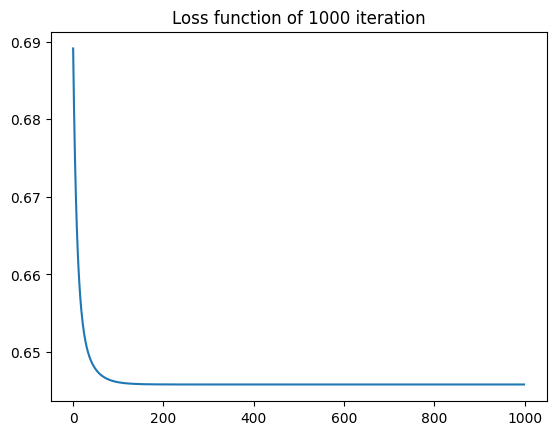

In [52]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")

In [53]:
storage = np.array(storage)

In [54]:
storage = storage[:,:,-1]
storage.shape

(1000, 2)

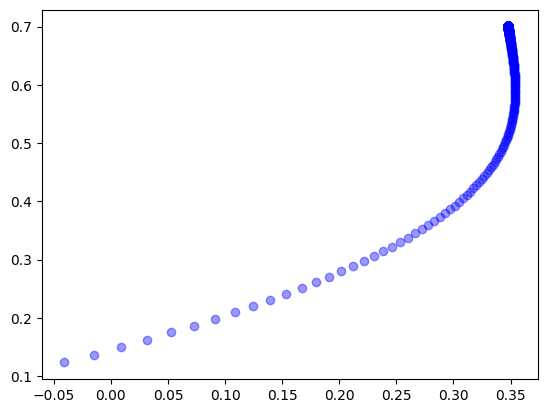

In [55]:
for x,y in storage:
    plt.scatter(x,y,color='blue',alpha=0.4)

# Standard Linear Regression

In [83]:
def generate_data(n,p):
    epsilon = 0.01
    size = (n,p)
    y_size = (n,1)
    x = np.random.normal(loc=1,scale=1,size=size)
    y = np.random.normal(0,2,size=y_size)
    return x,y

n = 50
p = 2
X_, y = generate_data(n,p)


def prediction(X,w,b):
    return X@w+b
def MSE(y,y_hat):
    return np.mean((y-y_hat)**2) / 2
def grad_MSE_b(y,X,w,b):
    return np.sum(X@w + b - y)
def grad_MSE_w(y,X,w,b):
    y_hat = prediction(X,w,b)
    return X.T@(y_hat-y)

def training_L(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    bias = np.random.normal(1)*np.ones_like(y)
    storage = []
    loss_storage = []
    for epoch in range(num_epochs):
        storage.append(weights)
        loss = MSE(y,prediction(X_,weights,bias))
        loss_storage.append(loss)
        if epoch % 100 == 0 :
            print(f"Epoch number {epoch}, weights {weights}, bias {bias[0]}")
        weights = weights - eta*grad_MSE_w(y,X_,weights,bias)
        bias = bias - eta*grad_MSE_b(y,X_,weights,bias)
    return storage, weights, bias
    
storage, weights, bias = training_L(X_,y,num_epochs=num_epochs)
storage=np.array(storage)
storage = storage[:,:,-1]

Epoch number 0, weights [[-0.37050044]
 [ 0.17616974]], bias [2.02490711]
Epoch number 100, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 200, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 300, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 400, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 500, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 600, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 700, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 800, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]
Epoch number 900, weights [[ 0.08072083]
 [-0.03355642]], bias [-0.00589688]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

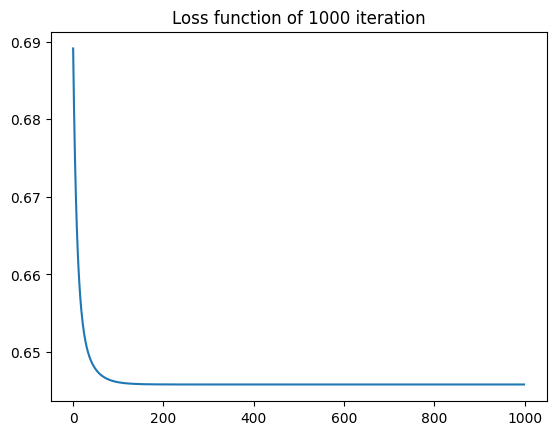

In [84]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")

Text(0.5, 0.5, 'Y Label')

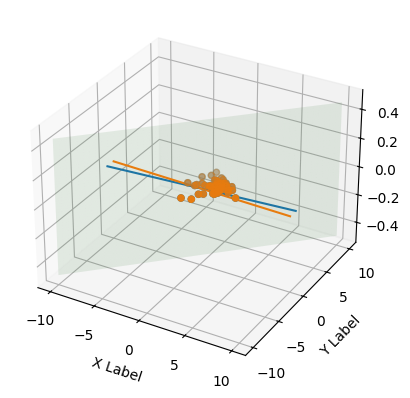

In [88]:
u = np.linspace(-10,10,50)
v = np.linspace(-10,10,50)
grid = np.meshgrid(u,v)
w = weights
b = bias
ax = plt.figure().add_subplot(projection='3d')
for i,vec in enumerate([u,v]):
    ax.plot(vec,w[i]*vec+b)

for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = X_[:,0]
    ys = X_[:,1]
    zs = y
    ax.scatter(xs, ys)
ax.plot_surface(u,v,prediction(np.column_stack([u,v]),weights,b),alpha=0.1)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')


In [90]:
weights.mean(),bias[0]

(np.float64(0.023582203520322045), array([-0.00589688]))

0 [-2.         -1.91836735 -1.83673469 -1.75510204 -1.67346939 -1.59183673
 -1.51020408 -1.42857143 -1.34693878 -1.26530612 -1.18367347 -1.10204082
 -1.02040816 -0.93877551 -0.85714286 -0.7755102  -0.69387755 -0.6122449
 -0.53061224 -0.44897959 -0.36734694 -0.28571429 -0.20408163 -0.12244898
 -0.04081633  0.04081633  0.12244898  0.20408163  0.28571429  0.36734694
  0.44897959  0.53061224  0.6122449   0.69387755  0.7755102   0.85714286
  0.93877551  1.02040816  1.10204082  1.18367347  1.26530612  1.34693878
  1.42857143  1.51020408  1.59183673  1.67346939  1.75510204  1.83673469
  1.91836735  2.        ]
1 [-2.         -1.91836735 -1.83673469 -1.75510204 -1.67346939 -1.59183673
 -1.51020408 -1.42857143 -1.34693878 -1.26530612 -1.18367347 -1.10204082
 -1.02040816 -0.93877551 -0.85714286 -0.7755102  -0.69387755 -0.6122449
 -0.53061224 -0.44897959 -0.36734694 -0.28571429 -0.20408163 -0.12244898
 -0.04081633  0.04081633  0.12244898  0.20408163  0.28571429  0.36734694
  0.44897959  0.5306122